In [49]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
%reload_ext autoreload

In [51]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from time import time_ns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 4
print(f"Currently using {DEVICE}")

Currently using cuda


In [52]:
%autoreload

In [53]:
from src.data_import import *
train_loader, test_loader = load_olivetti(batch_size=BATCH_SIZE, shuffle=True)

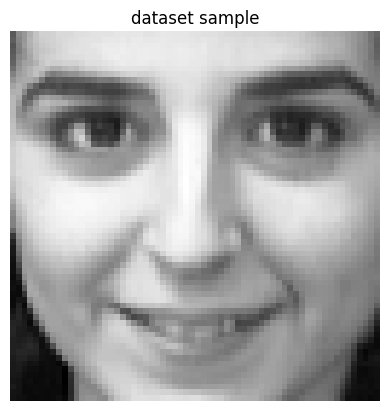

label: 9
shape: torch.Size([4, 1, 64, 64])


In [54]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample", cmap="gray")
#print label
print("label:", _[0].item())
print("shape:", x_real.shape)

In [55]:
n_heads = 3
IMAGE_SHAPE = (1, 64, 64)

In [56]:
from src.model import EBM

model = EBM(image_shape=IMAGE_SHAPE, n_heads=n_heads, batch_size=BATCH_SIZE)
for head in model.heads:
    head.to(DEVICE)

model.to(DEVICE)

EBM(
  (heads): ModuleList(
    (0-2): 3 x EnergyHead(
      (conv): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
      )
      (fc): Sequential(
        (0): Linear(in_features=16384, out_features=49, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=49, out_features=1, bias=True)
      )
    )
  )
)

In [57]:
from src.sampler import ReplaySampler

sampler = ReplaySampler(model, img_shape=IMAGE_SHAPE, buffer_size=600, noise_fraction=0.05, device=DEVICE)

In [58]:
from src.information import TotalCorrelationEstimator

total_correlation_estimator = TotalCorrelationEstimator(n_heads, hidden_dim=16, lr=1e-3)
total_correlation_estimator.to(DEVICE)

In [59]:
from src.train import train_one_epoch_TC, train_one_epoch
#torch.autograd.set_detect_anomaly(True, check_nan=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.000, 0.999))

for epoch in range(16):
    epoch_loss, _ = train_one_epoch_TC(
        model, 
        sampler, 
        train_loader, 
        optimizer,

        sample_steps=50,
        sample_step_size=10.0,
        sample_noise_std=0.005,
        energy_reg=1e-1,
        tc_regularizations=1e-2,
        
        tc_estimator=total_correlation_estimator,
        device=DEVICE
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

    if epoch % 5 == 0:
        pass # torch.save(model.state_dict(), f"./models/lfw/EBM_{epoch}_epochs_{len(model.heads)}_heads_{IMAGE_SHAPE}_shape_{time_ns()}t.pth")


100%|██████████| 70/70 [00:18<00:00,  3.75it/s]


Epoch 1, Loss: 0.2668


100%|██████████| 70/70 [00:18<00:00,  3.69it/s]


Epoch 2, Loss: 0.0002


100%|██████████| 70/70 [00:18<00:00,  3.72it/s]


...

Epoch 14, Loss: 0.0017


100%|██████████| 70/70 [00:18<00:00,  3.80it/s]


Epoch 15, Loss: 0.0010


100%|██████████| 70/70 [00:18<00:00,  3.80it/s]

Epoch 16, Loss: 0.0006


EBM DIAGNOSTICS

[1] Energy on real data
  Train  →  mean=-0.0383,  std=0.0315
  Test   →  mean=-0.0386,  std=0.0303
  |E_test - E_train| = 0.0003  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=-0.0585,  std=0.0192
  Gap (E_real_train - E_fake) = 0.0203  (WARNING: gap inverted)

[3] Energy on pure noise
  Noise  →  mean=4.4879,  std=0.1086
  Gap (E_real_train - E_noise) = -4.5261  (ok)

[4] Per-head energy (on train batch)
  Head 0  →  mean=0.2911,  std=0.0015
  Head 1  →  mean=-0.2346,  std=0.0243
  Head 2  →  mean=-0.0820,  std=0.0284
  Max off-diagonal correlation: 0.9408  (WARNING: heads are correlated)

[5] Replay buffer
  Buffer size: 600 / 600
  Buffer samples  →  mean=0.5534,  std=0.1708,  min=-0.5387,  max=1.0000

[6] Visual samples (Langevin from noise)


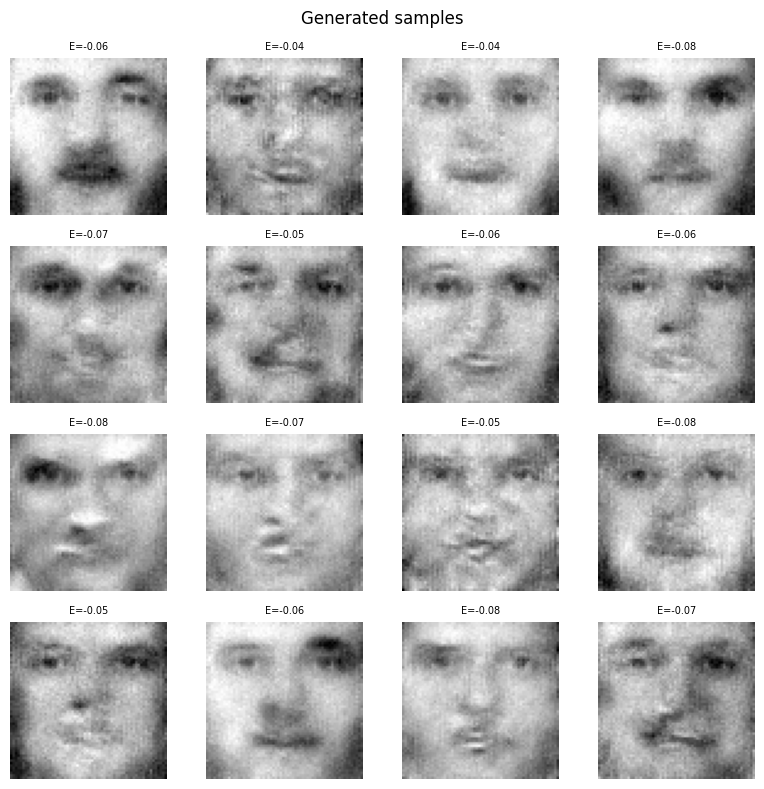


DONE


In [60]:
from src.diagnostic import diagnose

diagnose(model, sampler, IMAGE_SHAPE, train_loader, test_loader, device=DEVICE, n_samples=16)

In [61]:
model.to(DEVICE)

EBM(
  (heads): ModuleList(
    (0-2): 3 x EnergyHead(
      (conv): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
      )
      (fc): Sequential(
        (0): Linear(in_features=16384, out_features=49, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=49, out_features=1, bias=True)
      )
    )
  )
)

In [62]:
samples = sampler.generate(10, steps=600, step_size=10.0, noise_std=0.005)

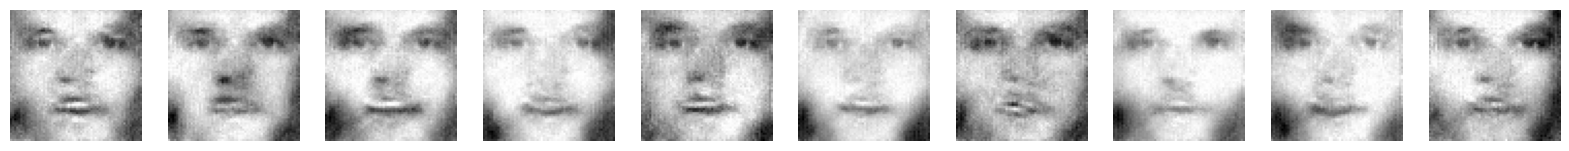

In [63]:
show_grid(samples, 10, cmap="gray")

In [64]:
# from src.plot import visualize_heads

# model.to("cpu")

# fig = visualize_heads(
#     model, 
#     steps=200, 
#     step_size=10.0, 
#     noise_std=0.01,
#     k=3,
#     cmap="Grays",
# )

# model.to(DEVICE)

In [65]:
# model = EBM(image_shape=(1,64,64), n_heads=3)
# mn = "EBM_20_epochs_(1, 64, 64)_shape_3_heads_1782902908565130435"
# f = "./models/olivetti/" + mn + ".pth"
# model.load_state_dict(torch.load(f))

In [66]:
from src.plot import visualize_head_gradients, visualize_head_abs_gradients

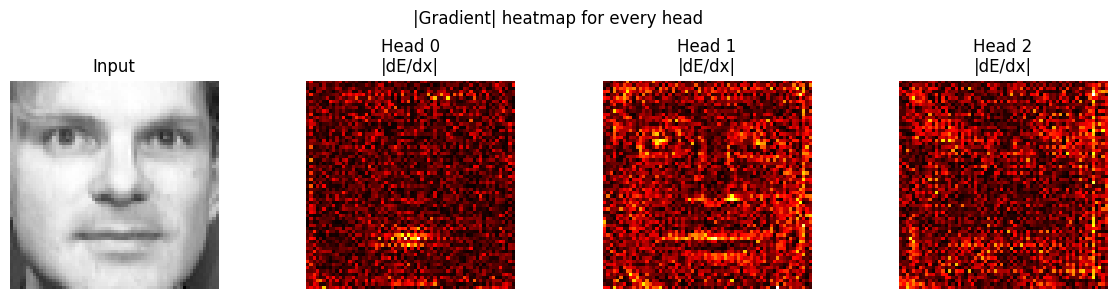

In [79]:
it = iter(test_loader)

for _ in range(6):
    it.__next__()
x0 = it.__next__()[0]

visualize_head_abs_gradients(model.to(DEVICE), x0, DEVICE)


In [ ]:
from src.gradient_inspect import synthetize_image_from_head, synthetize_image

class Combined(nn.Module):
    def __init__(self, m1, m2):
        super().__init__()
        self.m1 = m1
        self.m2 = m2
    def forward(self, x):
        return self.m1(x) + self.m2(x)

combined = 

img, _ = synthetize_image_from_head(combined, n_images=1, img_dimension=IMAGE_SHAPE[-1], steps=1_000)
show_single_sample(img, cmap="gray")


AttributeError: 'function' object has no attribute 'eval'

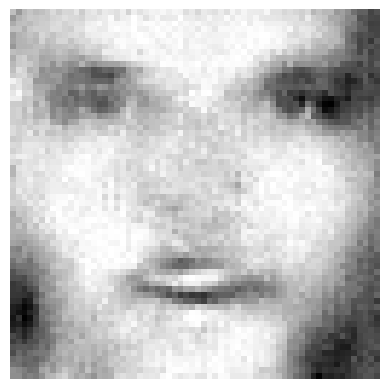

In [101]:
img, _ = synthetize_image(model.to("cpu"), img_dimension=IMAGE_SHAPE[-1], steps=1_000)
show_single_sample(img, cmap="gray")

In [ ]:
torch.save(model.state_dict(), f"./models/olivetti/EBM_{epoch}_epochs_{len(model.heads)}_heads_{IMAGE_SHAPE}_shape_{time_ns()}t.pth")